In [1]:
from apeGmsh import apeGmsh
from apeGmsh import Numberer, NumberedMesh
import numpy as np
import openseespy.opensees as ops

# Thick-Walled Cylinder — Quarter Model (Lamé Problem)

**Architecture: pyGmsh as mesh provider → OpenSeesPy as external solver**

This example demonstrates a clean separation of concerns:

- **pyGmsh** — geometry, meshing, physical groups, and post-processing views.
  It never imports or calls any solver.
- **OpenSeesPy** — FEM model building, analysis, and result extraction.
  It receives plain numpy arrays from apeGmsh and works independently.
- **Results go back to Gmsh** — we pass computed arrays to `g.view` for
  visualization in the Gmsh GUI. Again, no solver dependency in the View class.

This pattern makes pyGmsh reusable with *any* solver (OpenSees, FEniCS, Abaqus input decks, etc.).

In [2]:
# ============================================================
# Parameters
# ============================================================
#
# Thick-walled cylinder under internal pressure (Lamé problem):
#   - Quarter model exploiting double symmetry (x-axis and y-axis)
#   - Plane strain assumption (thk = 1.0, out-of-plane strain = 0)
#   - Analytical solution exists → good benchmark for FEM verification
#
inner_radius = 100.0    # [mm]  inner bore radius
outer_radius = 200.0    # [mm]  outer wall radius
lc           = 10.0     # [mm]  characteristic mesh size (controls density)

E   = 210.0e3   # [MPa]  Young's modulus  (steel ≈ 210 GPa)
nu  = 0.3       #  [-]   Poisson's ratio
p   = 100.0     # [MPa]  internal pressure applied on inner arc
thk = 1.0       # [mm]   unit thickness (plane strain formulation)

## Part 1 — Geometry & Mesh (pyGmsh)

Everything here is pure pyGmsh. No solver imports needed.

**Geometry workflow:**
1. Create points with `g.model.geometry.add_point()` — the `lc` parameter sets the
   target mesh element size at each point.
2. Connect points with lines and arcs — `add_arc(start, center, end)` uses
   the OCC kernel (not geo), so the center point is required but does **not**
   become a mesh node on the arc.
3. Form a closed curve loop → plane surface.
4. Define physical groups to tag boundaries and the domain — these are how
   we later query which nodes belong to which BC or load.

In [3]:
# Initialize pyGmsh — the context manager handles gmsh.initialize/finalize,
# but here we use manual .initialize() / .finalize() for notebook flexibility.
g = apeGmsh(model_name="Plate2D", verbose=True)
g.begin()

# --- Geometry: quarter annulus (OCC kernel) ---
#
#   p3 (0, R_o)
#    |  \  outer arc (l2)
#    |    \
#   l3     p2 (R_o, 0)
#    |    /
#    |  /  inner arc (l4)
#   p4 (0, R_i)          l1
#    ·----- p1 (R_i, 0) ---→ p2 (R_o, 0)
#   pc (0,0)
#
# Note: pc is the arc center. OCC creates it as a geometry point but it
# will NOT lie on the arcs. It does create an orphan mesh node at (0,0)
# which we filter out later via used_tags.

pc = g.model.geometry.add_point(0, 0, 0, lc=lc, label="center")
p1 = g.model.geometry.add_point(inner_radius, 0, 0, lc=lc, label="inner_x")
p2 = g.model.geometry.add_point(outer_radius, 0, 0, lc=lc, label="outer_x")
p3 = g.model.geometry.add_point(0, outer_radius, 0, lc=lc, label="outer_y")
p4 = g.model.geometry.add_point(0, inner_radius, 0, lc=lc, label="inner_y")

# 2 radial lines + 2 circular arcs (CCW winding)
l1 = g.model.geometry.add_line(p1, p2, label="bottom")         # radial line along x-axis
l2 = g.model.geometry.add_arc(p2, pc, p3, label="outer_arc")   # outer arc: R_o
l3 = g.model.geometry.add_line(p3, p4, label="left")            # radial line along y-axis
l4 = g.model.geometry.add_arc(p4, pc, p1, label="inner_arc")   # inner arc: R_i

# Close the loop and create the surface
loop = g.model.geometry.add_curve_loop([l1, l2, l3, l4])
surf = g.model.geometry.add_plane_surface(loop, label="plate")

# Inspect what we built
g.model.queries.registry()

Gmsh version: 4.15.1
[Model] add_point(0, 0, 0) → tag 1
[Model] add_point(100.0, 0, 0) → tag 2
[Model] add_point(200.0, 0, 0) → tag 3
[Model] add_point(0, 200.0, 0) → tag 4
[Model] add_point(0, 100.0, 0) → tag 5
[Model] add_line(2 → 3) → tag 1
[Model] add_arc(start=3, centre=1, end=4) → tag 2
[Model] add_line(4 → 5) → tag 3
[Model] add_arc(start=5, centre=1, end=2) → tag 4
[Model] add_curve_loop([1, 2, 3, 4]) → tag 1
[Model] add_plane_surface(wires=[1]) → tag 1


label           kind
dim tag                             
0   1          center          point
    2         inner_x          point
    3         outer_x          point
    4         outer_y          point
    5         inner_y          point
1   1    curve_loop_1     curve_loop
    2       outer_arc            arc
    3            left           line
    4       inner_arc            arc
2   1           plate  plane_surface

In [4]:
# --- Physical groups ---
#
# Physical groups label geometry entities so we can later query
# "give me all mesh nodes on this boundary". The tag returned by
# g.physical.add() is what we pass to g.physical.get_nodes().
#
# dim=1 → curves (boundaries), dim=2 → surfaces (domain)

pg_symY = g.physical.add(1, [l1], name="Sym_Y")      # bottom edge → uy = 0
pg_symX = g.physical.add(1, [l3], name="Sym_X")      # left edge   → ux = 0
pg_pres = g.physical.add(1, [l4], name="Pressure")   # inner arc   → pressure load
pg_plat = g.physical.add(2, [surf], name="Plate")    # domain      → element region

g.physical.summary()

[PhysicalGroups] add(dim=1, entities=[1]) → pg_tag=1, name='Sym_Y'
[PhysicalGroups] add(dim=1, entities=[3]) → pg_tag=2, name='Sym_X'
[PhysicalGroups] add(dim=1, entities=[4]) → pg_tag=3, name='Pressure'
[PhysicalGroups] add(dim=2, entities=[1]) → pg_tag=4, name='Plate'

--- Physical Groups ---
                name  n_entities entity_tags
dim pg_tag                                  
1   1          Sym_Y           1           1
    2          Sym_X           1           3
    3       Pressure           1           4
2   4          Plate           1           1


name  n_entities entity_tags
dim pg_tag                                  
1   1          Sym_Y           1           1
    2          Sym_X           1           3
    3       Pressure           1           4
2   4          Plate           1           1

In [5]:
# --- Generate mesh ---
#
# set_order(1) → linear elements (3-node triangles for 2D)
# generate(2)  → mesh the 2D surfaces
#
# The mesh is stored inside Gmsh's internal state. We extract it
# in the next cell with get_fem_data().

g.mesh.generation.set_order(1)
g.mesh.generation.generate(2)

g.mesh.partitioning.renumber(method='rcm')

[Mesh] set_order(1)
[Mesh] generate(dim=2)
[Mesh] get_nodes → 331 nodes
[Mesh] get_elements → 590 elements (1 types)
[Mesh] renumber_mesh(method='rcm'): 331 nodes, 590 elements, bandwidth=24


## Part 2 — Extract mesh data & Renumber

Two paths for mesh extraction:

1. **`get_fem_data()`** — raw Gmsh tags (non-contiguous, may have orphans)
2. **`get_numbered_mesh()`** — contiguous solver-ready IDs via the Numberer

We use both here: `get_fem_data()` for the raw data and boundary queries,
then `get_numbered_mesh()` for the solver. The `NumberedMesh` object provides:

| Attribute               | Description                                    |
|-------------------------|------------------------------------------------|
| `node_ids`              | Contiguous 1-based solver node IDs             |
| `node_coords`           | Coordinates aligned with `node_ids`            |
| `elem_ids`              | Contiguous 1-based solver element IDs          |
| `connectivity`          | Element→node matrix in solver IDs              |
| `gmsh_to_solver_node`   | Gmsh tag → solver ID map                       |
| `solver_to_gmsh_node`   | Solver ID → Gmsh tag map                       |
| `gmsh_to_solver_elem`   | Gmsh element tag → solver element ID           |
| `bandwidth`             | Semi-bandwidth of the connectivity             |

The Numberer automatically handles orphan filtering (`used_only=True`
by default), so the center point at (0,0) is excluded — no manual
`used_tags` check needed.

In [6]:
# --- Raw FEM data (still needed for boundary queries + plotting) ---
fem = g.mesh.queries.get_fem_data(dim=2)

node_tags    = fem.nodes.ids      # (N,)        Gmsh node IDs
node_coords  = fem.nodes.coords     # (N, 3)      XYZ
connectivity = fem.elements.connectivity    # (nElem, 3)   node-tag matrix (Gmsh tags)
elem_tags    = fem.elements.ids    # [int, ...]   Gmsh element tags

# --- Boundary nodes from physical groups ---
# These come back as Gmsh tags — we translate them to solver IDs
# via the bidirectional map.

bottom_nodes_gmsh = g.physical.get_nodes(1, pg_symY)['tags']   # uy = 0
left_nodes_gmsh   = g.physical.get_nodes(1, pg_symX)['tags']   # ux = 0
inner_nodes_gmsh  = g.physical.get_nodes(1, pg_pres)['tags']   # pressure

# --- Inner arc edges (1D line elements on l4) ---
# For pressure loads, we need the 1D edge connectivity on the inner arc.
# These are in Gmsh tags — we'll translate when applying loads.

inner_elems = g.mesh.queries.get_elements(dim=1, tag=l4)
inner_edges = []
for etype, enodes in zip(inner_elems['types'], inner_elems['node_tags']):
    props = g.mesh.queries.get_element_properties(etype)
    inner_edges = enodes.reshape(-1, props['n_nodes']).astype(int)
    
g.mesh.viewer()

fem_data = g.mesh.queries.get_fem_data()


[FEMData] WARNING: 1 orphan node(s) removed (not connected to any element). Tags: [331]
[Mesh] get_fem_data(dim=2) → 330 nodes, 590 elements, bw=314
[PhysicalGroups] get_nodes(dim=1, pg='Sym_Y') → 11 nodes
[PhysicalGroups] get_nodes(dim=1, pg='Sym_X') → 11 nodes
[PhysicalGroups] get_nodes(dim=1, pg='Pressure') → 17 nodes
[Mesh] get_elements → 16 elements (1 types)
[MeshViewer] closed — 0 nodes picked, 0 elements picked, 0 BRep patches selected
[FEMData] WARNING: 1 orphan node(s) removed (not connected to any element). Tags: [331]
[Mesh] get_fem_data(dim=2) → 330 nodes, 590 elements, bw=314


## Part 3 — OpenSees Model (using Numberer)

The `NumberedMesh` gives us contiguous 1-based IDs and connectivity
ready for OpenSees. No more manual `gmsh_to_ops` loop — the Numberer
handles orphan filtering, contiguous renumbering, and bidirectional
maps automatically.

For boundary conditions and loads, we use `mesh.gmsh_to_solver_node`
to translate Gmsh physical-group tags to solver IDs.

In [7]:
fem_data.inspect.physical_table()

name  n_nodes  n_elems
dim pg_tag                            
1   1          Sym_Y       11       10
    2          Sym_X       11       10
    3       Pressure       17       16
2   4          Plate      330      590

In [8]:
ops.wipe()
ops.model("basic", "-ndm", 2, "-ndf", 2)

# --- Nodes (from NumberedMesh) ---
# Contiguous IDs, orphans already filtered out.
for node_id, coords in zip(fem_data.nodes.ids, fem_data.nodes.coords):
    ops.node(node_id, *coords)

# --- Material ---
ops.nDMaterial("ElasticIsotropic", 1, E, nu)

# --- Elements (from NumberedMesh) ---
# connectivity is already in solver IDs — feed directly to OpenSees.
for element_id, conn in zip(*fem_data.elements.resolve(element_type='tri3')):
    ops.element("tri31", element_id, *conn, thk, "PlaneStrain", 1)

# --- Boundary conditions (symmetry) ---
# Translate Gmsh physical-group tags → solver IDs via the map.
for node_id in fem_data.physical.get_nodes(dim=1, tag=1)['tags']:   # pg_symY
    ops.fix(node_id, 0, 1)   # fix uy, free ux
for node_id in fem_data.physical.get_nodes(dim=1, tag=2)['tags']:   # pg_symX
    ops.fix(node_id, 1, 0)   # fix ux, free uy
    


Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


In [9]:
# --- Consistent nodal forces for internal pressure ---
#
# For a 2-node linear edge of length L with traction t_i, t_j at each node:
#
#     F_i = (L/6)(2·t_i + t_j)
#     F_j = (L/6)(t_i + 2·t_j)
#
# From the consistent load vector: F = ∫ N^T · t dΓ
# Traction direction is radially outward: t = p · n̂,  n̂ = (x/r, y/r)

ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)

# Get edge elements on inner arc directly from FEMData's physical groups
inner = (lambda _ids_conn: {'ids': _ids_conn[0], 'connectivity': _ids_conn[1]})(fem.elements.resolve(pg=pg_pres, dim=1))
inner_edges = inner['connectivity']          # (nEdge, 2), already solver IDs

nodal_forces = {}

for edge in inner_edges:
    n1, n2 = int(edge[0]), int(edge[1])

    # Coordinates via FEMData lookup
    x1, y1, _ = fem.get_node_coords(n1)
    x2, y2, _ = fem.get_node_coords(n2)

    # Edge length and radii
    Le = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    r1 = np.sqrt(x1**2 + y1**2)
    r2 = np.sqrt(x2**2 + y2**2)

    # Traction at each node: t = p · (x/r, y/r)
    tx1, ty1 = p * x1/r1, p * y1/r1
    tx2, ty2 = p * x2/r2, p * y2/r2

    # Consistent nodal forces
    Fx1 = (Le/6) * (2*tx1 + tx2);  Fy1 = (Le/6) * (2*ty1 + ty2)
    Fx2 = (Le/6) * (tx1 + 2*tx2);  Fy2 = (Le/6) * (ty1 + 2*ty2)

    # Accumulate (shared nodes get contributions from adjacent edges)
    nodal_forces.setdefault(n1, [0., 0.])
    nodal_forces.setdefault(n2, [0., 0.])
    nodal_forces[n1][0] += Fx1;  nodal_forces[n1][1] += Fy1
    nodal_forces[n2][0] += Fx2;  nodal_forces[n2][1] += Fy2

for nid, (fx, fy) in nodal_forces.items():
    ops.load(nid, fx, fy)

print(f"Pressure applied to {len(nodal_forces)} nodes")

Pressure applied to 17 nodes


## Part 4 — Analysis & Post-processing

Static linear analysis in one load step. After solving, we extract
displacements and stresses into plain numpy arrays and call `ops.wipe()`
to release OpenSees. From this point on, OpenSees is completely done.

In [10]:
# --- Solve ---
#
# Static analysis setup:
#   Transformation constraints → handles multi-point constraints correctly
#   RCM numberer              → Reverse Cuthill-McKee bandwidth reduction
#   BandGeneral system        → banded solver (efficient for 2D meshes)
#   NormDispIncr test         → convergence on displacement increment norm
#   Newton algorithm          → full Newton-Raphson (1 iteration for linear)
#   LoadControl integrator    → apply full load in 1 step (λ = 1.0)

ops.constraints("Transformation")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.test("NormDispIncr", 1.0e-8, 10)
ops.algorithm("Newton")
ops.integrator("LoadControl", 1.0)
ops.analysis("Static")

ok = ops.analyze(1)
print("CONVERGED" if ok == 0 else "FAILED")

CONVERGED


## 9. Capture results — manual + DomainCapture paths

Two ways to produce a native-HDF5 results file consumable by the
apeGmsh ``ResultsViewer``:

1. **Manual path** — query the live OpenSees domain post-analysis,
   open a ``NativeWriter``, and write nodal displacements yourself.
   Good for one-shot snapshots and post-hoc diagnostics.
2. **DomainCapture path** — declare what to capture with
   ``Recorders().nodes(...)``, hand the spec to a ``DomainCapture``
   context, and call ``cap.step(t=...)`` after each ``ops.analyze``
   (the helper does it for you). Scales to multi-stage, transient,
   modal, and multi-recorder runs.

Both produce a file that ``Results.from_native(path).viewer()`` can
open. The viewer launch is gated on ``APEGMSH_SKIP_VIEWER`` so this
notebook is safe to run under nbconvert / CI.


In [ ]:
from apeGmsh import workdir
OUT = workdir()
# DomainCapture path: declarative recorders, capture during analyze.
from apeGmsh.solvers.Recorders import Recorders
from apeGmsh.results.capture._domain import DomainCapture

recs = Recorders()
recs.nodes(components="displacement")
recs.nodes(components="reaction_force")
spec = recs.resolve(fem, ndm=2, ndf=2)

results_capture = OUT / "capture.h5"
if results_capture.exists():
    results_capture.unlink()

with DomainCapture(spec, results_capture, fem, ndm=2, ndf=2) as cap:
    cap.begin_stage("run", kind="static")
    # --- copied from cell 11 ---
    ops.wipe()
    ops.model("basic", "-ndm", 2, "-ndf", 2)

    # --- Nodes (from NumberedMesh) ---
    # Contiguous IDs, orphans already filtered out.
    for node_id, coords in zip(fem_data.nodes.ids, fem_data.nodes.coords):
        ops.node(node_id, *coords)

    # --- Material ---
    ops.nDMaterial("ElasticIsotropic", 1, E, nu)

    # --- Elements (from NumberedMesh) ---
    # connectivity is already in solver IDs — feed directly to OpenSees.
    for element_id, conn in zip(*fem_data.elements.resolve(element_type='tri3')):
        ops.element("tri31", element_id, *conn, thk, "PlaneStrain", 1)

    # --- Boundary conditions (symmetry) ---
    # Translate Gmsh physical-group tags → solver IDs via the map.
    for node_id in fem_data.physical.get_nodes(dim=1, tag=1)['tags']:   # pg_symY
        ops.fix(node_id, 0, 1)   # fix uy, free ux
    for node_id in fem_data.physical.get_nodes(dim=1, tag=2)['tags']:   # pg_symX
        ops.fix(node_id, 1, 0)   # fix ux, free uy
    # --- copied from cell 12 ---
    # --- Consistent nodal forces for internal pressure ---
    #
    # For a 2-node linear edge of length L with traction t_i, t_j at each node:
    #
    #     F_i = (L/6)(2·t_i + t_j)
    #     F_j = (L/6)(t_i + 2·t_j)
    #
    # From the consistent load vector: F = ∫ N^T · t dΓ
    # Traction direction is radially outward: t = p · n̂,  n̂ = (x/r, y/r)

    ops.timeSeries("Linear", 1)
    ops.pattern("Plain", 1, 1)

    # Get edge elements on inner arc directly from FEMData's physical groups
    inner = (lambda _ids_conn: {'ids': _ids_conn[0], 'connectivity': _ids_conn[1]})(fem.elements.resolve(pg=pg_pres, dim=1))
    inner_edges = inner['connectivity']          # (nEdge, 2), already solver IDs

    nodal_forces = {}

    for edge in inner_edges:
        n1, n2 = int(edge[0]), int(edge[1])

        # Coordinates via FEMData lookup
        x1, y1, _ = fem.get_node_coords(n1)
        x2, y2, _ = fem.get_node_coords(n2)

        # Edge length and radii
        Le = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        r1 = np.sqrt(x1**2 + y1**2)
        r2 = np.sqrt(x2**2 + y2**2)

        # Traction at each node: t = p · (x/r, y/r)
        tx1, ty1 = p * x1/r1, p * y1/r1
        tx2, ty2 = p * x2/r2, p * y2/r2

        # Consistent nodal forces
        Fx1 = (Le/6) * (2*tx1 + tx2);  Fy1 = (Le/6) * (2*ty1 + ty2)
        Fx2 = (Le/6) * (tx1 + 2*tx2);  Fy2 = (Le/6) * (ty1 + 2*ty2)

        # Accumulate (shared nodes get contributions from adjacent edges)
        nodal_forces.setdefault(n1, [0., 0.])
        nodal_forces.setdefault(n2, [0., 0.])
        nodal_forces[n1][0] += Fx1;  nodal_forces[n1][1] += Fy1
        nodal_forces[n2][0] += Fx2;  nodal_forces[n2][1] += Fy2

    for nid, (fx, fy) in nodal_forces.items():
        ops.load(nid, fx, fy)

    print(f"Pressure applied to {len(nodal_forces)} nodes")
    # --- copied from cell 14 ---
    # --- Solve ---
    #
    # Static analysis setup:
    #   Transformation constraints → handles multi-point constraints correctly
    #   RCM numberer              → Reverse Cuthill-McKee bandwidth reduction
    #   BandGeneral system        → banded solver (efficient for 2D meshes)
    #   NormDispIncr test         → convergence on displacement increment norm
    #   Newton algorithm          → full Newton-Raphson (1 iteration for linear)
    #   LoadControl integrator    → apply full load in 1 step (λ = 1.0)

    ops.constraints("Transformation")
    ops.numberer("RCM")
    ops.system("BandGeneral")
    ops.test("NormDispIncr", 1.0e-8, 10)
    ops.algorithm("Newton")
    ops.integrator("LoadControl", 1.0)
    ops.analysis("Static")

    ok = ops.analyze(1)
    cap.step(t=ops.getTime())
    print("CONVERGED" if ok == 0 else "FAILED")
    cap.end_stage()

print(f"capture -> {results_capture} ({results_capture.stat().st_size/1024:.1f} KB)")


In [ ]:
# Open the captured run in the apeGmsh ResultsViewer (subprocess, non-blocking).
# Set APEGMSH_SKIP_VIEWER=1 in the environment to skip the GUI under nbconvert / CI.
from apeGmsh.results import Results
results = Results.from_native(results_capture)
results.viewer(blocking=False)


In [12]:
# --- Extract results into plain numpy arrays ---
#
# After renumber_mesh(), fem.nodes.ids and fem.elements.ids ARE the
# solver IDs.  No Gmsh↔solver translation is needed — we index
# directly into the FEMData arrays.

nNode = fem.info.n_nodes
nElem = fem.info.n_elems

# -- Displacements --
disp = np.zeros((nNode, 2))
for i, nid in enumerate(fem.nodes.ids):
    disp[i, 0] = ops.nodeDisp(int(nid), 1)   # ux
    disp[i, 1] = ops.nodeDisp(int(nid), 2)   # uy

# -- Radial displacement --
# u_r = (x·ux + y·uy) / r  — projection onto radial direction.
r_nodes = np.sqrt(fem.nodes.coords[:, 0]**2 + fem.nodes.coords[:, 1]**2)
r_safe  = np.where(r_nodes > 1e-12, r_nodes, 1.0)
ur = (fem.nodes.coords[:, 0]*disp[:, 0] + fem.nodes.coords[:, 1]*disp[:, 1]) / r_safe

# -- Element stresses --
# tri31 (CST) returns one constant stress per element: [σxx, σyy, σxy]
sig_xx = np.zeros(nElem)
sig_yy = np.zeros(nElem)
sig_xy = np.zeros(nElem)

for i, eid in enumerate(fem.elements.ids):
    s = ops.eleResponse(int(eid), "stresses")
    sig_xx[i] = s[0]
    sig_yy[i] = s[1]
    sig_xy[i] = s[2]

# -- Nodal-averaged σ_xx --
# CST gives piecewise-constant stress. Nodal averaging: for each node,
# average the stress from all elements sharing that node.
conn_idx = np.array([[fem.nodes.index(n) for n in row] for row in fem.elements.connectivity])
sig_xx_nodal = np.zeros(nNode)
node_count   = np.zeros(nNode)

for e in range(nElem):
    for ln in range(3):
        nidx = conn_idx[e, ln]
        sig_xx_nodal[nidx] += sig_xx[e]
        node_count[nidx]   += 1.0

node_count[node_count == 0] = 1.0
sig_xx_nodal /= node_count

print(f"u_r  range: [{ur.min():.6f}, {ur.max():.6f}] mm")
print(f"σ_xx range: [{sig_xx.min():.2f}, {sig_xx.max():.2f}] MPa")

# --- Done with OpenSees ---
ops.wipe()

u_r  range: [0.057372, 0.090446] mm
σ_xx range: [-101.83, 174.50] MPa


## Part 5 — Matplotlib Plots

Quick visual checks using matplotlib before launching the Gmsh GUI.
These use the same numpy arrays — no solver or Gmsh calls needed.

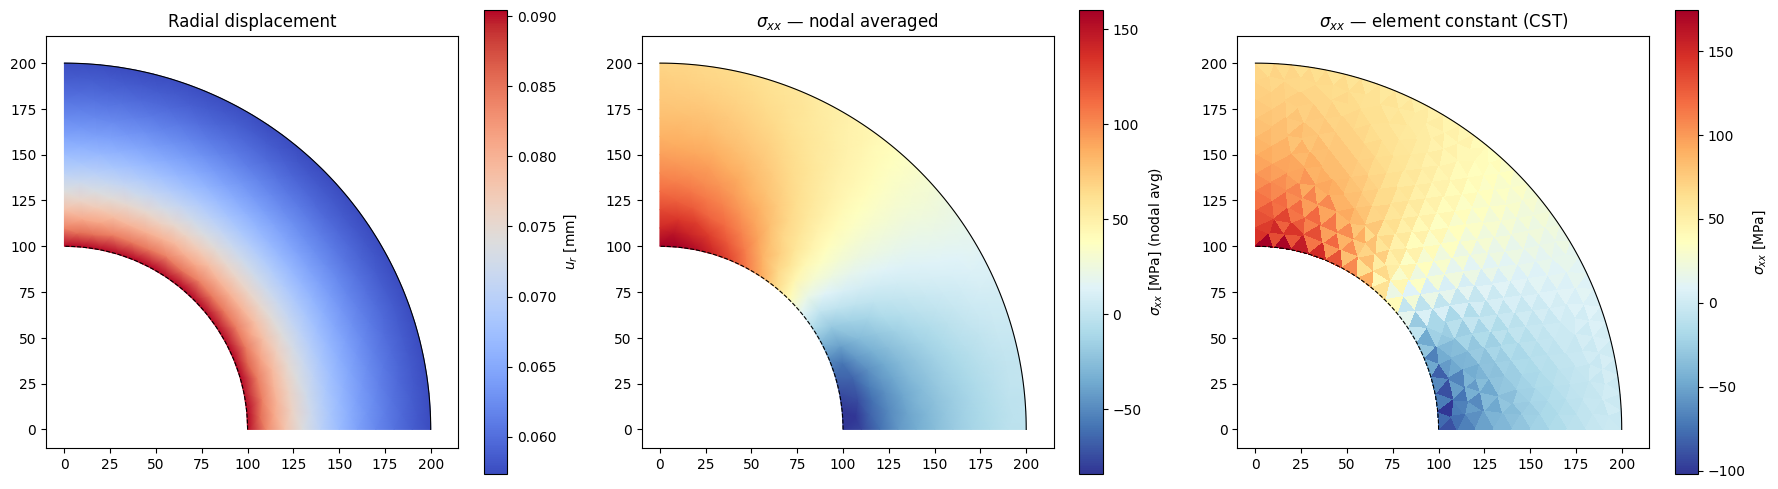

In [13]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# Triangulation for matplotlib — uses array indices, not Gmsh tags
triang = mtri.Triangulation(node_coords[:, 0], node_coords[:, 1], conn_idx)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Radial displacement contour
ax = axes[0]
tripc = ax.tripcolor(triang, ur, shading='gouraud', cmap='coolwarm')
plt.colorbar(tripc, ax=ax, label=r"$u_r$ [mm]")
ax.set_title("Radial displacement")
ax.set_aspect('equal')

# (b) Nodal-averaged σ_xx contour
ax = axes[1]
tripc2 = ax.tripcolor(triang, sig_xx_nodal, shading='gouraud', cmap='RdYlBu_r')
plt.colorbar(tripc2, ax=ax, label=r"$\sigma_{xx}$ [MPa] (nodal avg)")
ax.set_title(r"$\sigma_{xx}$ — nodal averaged")
ax.set_aspect('equal')

# (c) Element-constant σ_xx (raw CST output)
ax = axes[2]
triplt = ax.tripcolor(triang, sig_xx, shading='flat', cmap='RdYlBu_r')
plt.colorbar(triplt, ax=ax, label=r"$\sigma_{xx}$ [MPa]")
ax.set_title(r"$\sigma_{xx}$ — element constant (CST)")
ax.set_aspect('equal')

# Overlay inner/outer boundaries
theta = np.linspace(0, np.pi/2, 100)
for ax in axes:
    ax.plot(inner_radius*np.cos(theta), inner_radius*np.sin(theta), "k--", lw=0.8)
    ax.plot(outer_radius*np.cos(theta), outer_radius*np.sin(theta), "k-", lw=0.8)
    ax.set_xlim(-10, outer_radius+15)
    ax.set_ylim(-10, outer_radius+15)

plt.tight_layout()
plt.show()

## Part 6 — Gmsh Post-processing Views

Pass the numpy result arrays back to pyGmsh for visualization in the Gmsh GUI.
The `g.view` methods are **solver-agnostic** — they accept plain arrays and
element/node tag lists, never importing OpenSees.

| Method                    | Data lives at… | Smoothing        |
|---------------------------|----------------|------------------|
| `add_element_scalar()`    | elements       | piecewise-const  |
| `add_element_vector()`    | elements       | piecewise-const  |
| `add_node_scalar()`       | nodes          | Gouraud-smooth   |
| `add_node_vector()`       | nodes          | Gouraud-smooth   |

In [15]:
# --- Gmsh post-processing views ---
#
# Element-constant stress (raw CST):
elem_ids_list = list(fem.elements.ids.astype(int))
g.view.add_element_scalar("sig_xx (elem)", elem_ids_list, sig_xx)
g.view.add_element_scalar("sig_yy (elem)", elem_ids_list, sig_yy)
g.view.add_element_scalar("sig_xy (elem)", elem_ids_list, sig_xy)

# Nodal fields (smooth):
node_ids_list = list(fem.nodes.ids.astype(int))
g.view.add_node_scalar("sig_xx (nodal avg)", node_ids_list, sig_xx_nodal)
g.view.add_node_scalar("u_r", node_ids_list, ur)
g.view.add_node_vector("displacement", node_ids_list, disp)

print(f"Created {g.view.count()} Gmsh views")

[View] add_element_scalar('sig_xx (elem)') → view 4  (590 elements)
[View] add_element_scalar('sig_yy (elem)') → view 5  (590 elements)
[View] add_element_scalar('sig_xy (elem)') → view 6  (590 elements)
[View] add_node_scalar('sig_xx (nodal avg)') → view 7  (330 nodes)
[View] add_node_scalar('u_r') → view 8  (330 nodes)
[View] add_node_vector('displacement') → view 9  (330 nodes)
Created 9 Gmsh views


## Part 7 — Alternative paths: Numberer vs manual

This notebook uses the **Numberer** path (recommended). Here's how the
options compare:

| Scenario                           | Recommended path              |
|------------------------------------|-------------------------------|
| Standard workflow (most cases)     | `get_numbered_mesh()` + maps  |
| Custom edge loads (like this one!) | Numberer + raw `get_fem_data` |
| Bandwidth optimisation needed      | `get_numbered_mesh(method="rcm")` |
| Multi-material with different elems| Numberer + physical group maps|
| Teaching / understanding the flow  | This notebook!                |

The Numberer replaces the old manual `gmsh_to_ops` loop:

```python
# OLD (manual):
gmsh_to_ops = {}
new_id = 0
for gtag, coords in zip(node_tags, node_coords):
    if int(gtag) not in used_tags:
        continue
    new_id += 1
    gmsh_to_ops[int(gtag)] = new_id
    ops.node(new_id, float(coords[0]), float(coords[1]))

# NEW (Numberer):
mesh = g.mesh.get_numbered_mesh(dim=2, method="simple")
for i in range(mesh.n_nodes):
    ops.node(int(mesh.node_ids[i]), *mesh.node_coords[i])
# Maps: mesh.gmsh_to_solver_node, mesh.solver_to_gmsh_node
```

## Part 8 — Launch Gmsh GUI & Finalize

In [18]:
# Launch the Gmsh GUI to interactively explore the views
# (close the window to continue to the next cell)
g.model.gui()

In [19]:
# Release Gmsh resources
g.end()